# Support vector machines: the basics

A **support vector machine (SVM)** is a way of sorting things into two groups. It draws a line between the groups, and it picks the line that leaves the **widest possible gap** between them.

In this notebook we will:

1. Look at some simple data with two groups
2. Train an SVM and draw the line it finds
3. Find the **support vectors**, the points that decide where the line goes
4. Use the line to make predictions
5. See what happens when a straight line is not enough

Run each cell in order with **Shift + Enter**.

## Key words

| Word | Meaning |
|---|---|
| **Boundary** | The line that separates the two groups |
| **Margin** | The gap between the boundary and the closest points on each side |
| **Support vectors** | The points that sit right on the edge of the margin |
| **Kernel** | A trick that lets an SVM draw curved boundaries |

## Step 1: Setting up

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

## Step 2: The data

We have 20 made-up points. Each one has two features (an x and a y value) and belongs to **group A** or **group B**.

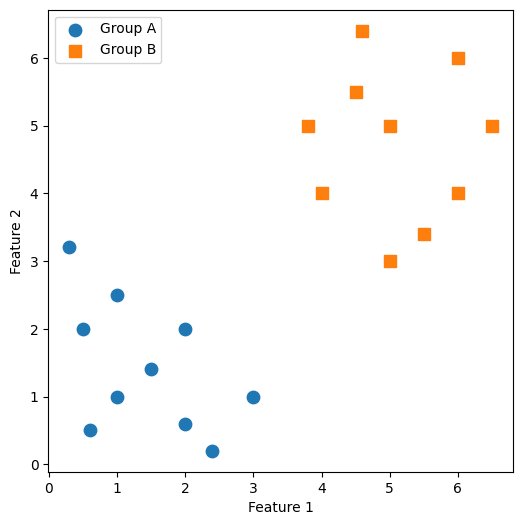

In [2]:
group_A = np.array([[2, 2], [3, 1], [1, 2.5], [1, 1], [0.5, 2],
                    [2, 0.6], [1.5, 1.4], [0.6, 0.5], [2.4, 0.2], [0.3, 3.2]])
group_B = np.array([[4, 4], [5, 3], [5, 5], [6, 4], [4.5, 5.5],
                    [6, 6], [3.8, 5], [5.5, 3.4], [6.5, 5], [4.6, 6.4]])

X = np.vstack([group_A, group_B])        # all 20 points
y = np.array([0] * 10 + [1] * 10)        # labels: 0 = group A, 1 = group B

plt.figure(figsize=(6, 6))
plt.scatter(group_A[:, 0], group_A[:, 1], color="tab:blue", s=80, label="Group A")
plt.scatter(group_B[:, 0], group_B[:, 1], color="tab:orange", marker="s", s=80, label="Group B")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

You could draw lots of different straight lines between these two groups. Which one is best? An SVM picks the one that stays **as far away as possible** from both groups.

## Step 3: Train the SVM

We use `SVC` from scikit-learn with a **linear** kernel, which means a straight line. (The setting `C=1000` tells it to be strict and not allow any points on the wrong side. We come back to `C` at the end.)

In [3]:
model = SVC(kernel="linear", C=1000)
model.fit(X, y)
print("Training finished")

Training finished


## Step 4: Draw the line and the margin

The function below draws the data, the boundary (solid line) and the edges of the margin (dashed lines). You do not need to understand every line of it.

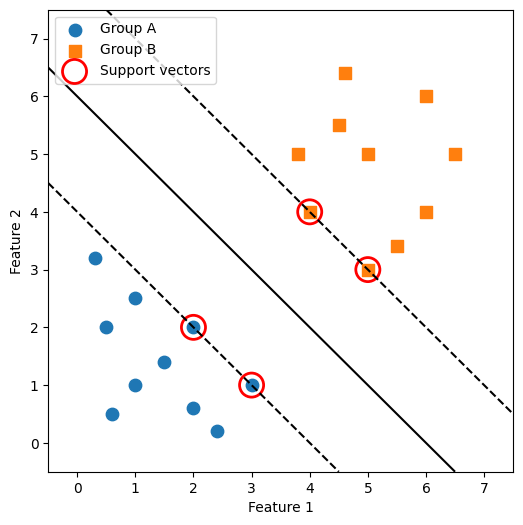

In [4]:
def draw_svm(model, X, y):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color="tab:blue", s=80, label="Group A")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color="tab:orange", marker="s", s=80, label="Group B")

    # work out the model's score at every point on a grid
    xx, yy = np.meshgrid(np.linspace(-0.5, 7.5, 200), np.linspace(-0.5, 7.5, 200))
    scores = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # score 0 is the boundary, -1 and +1 are the edges of the margin
    plt.contour(xx, yy, scores, levels=[-1, 0, 1], colors="black", linestyles=["--", "-", "--"])

    # circle the support vectors
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=300, facecolors="none", edgecolors="red", linewidths=2, label="Support vectors")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(loc="upper left")
    plt.show()

draw_svm(model, X, y)

- The **solid line** is the boundary. Everything on one side is predicted group A, everything on the other side group B.
- The **dashed lines** are the edges of the margin. Think of the boundary as the middle of a road, and the dashed lines as the kerbs.
- The SVM made this road **as wide as it could** without any points standing in it.

## Step 5: The support vectors

The points circled in red sit exactly on the edges of the road. These are the **support vectors**. Let's print them.

In [5]:
print("Support vectors:")
print(model.support_vectors_)
print()
print("Number of support vectors:", len(model.support_vectors_), "out of", len(X), "points")

Support vectors:
[[2. 2.]
 [3. 1.]
 [4. 4.]
 [5. 3.]]

Number of support vectors: 4 out of 20 points


Only these few points decide where the line goes. To prove it, let's **delete a point that is not a support vector** (the point at (0.6, 0.5), far from the line) and train again.

In [6]:
keep = ~((X[:, 0] == 0.6) & (X[:, 1] == 0.5))      # every point except (0.6, 0.5)
model_2 = SVC(kernel="linear", C=1000)
model_2.fit(X[keep], y[keep])

print("Line before:", model.coef_.round(2), model.intercept_.round(2))
print("Line after: ", model_2.coef_.round(2), model_2.intercept_.round(2))

Line before: [[0.5 0.5]] [-3.]
Line after:  [[0.5 0.5]] [-3.]


The line is exactly the same. Points far from the boundary make no difference at all. Only the support vectors matter, which is where the name comes from.

## Step 6: Making predictions

The SVM has learned a simple formula. It gives each point a **score**:

> score = w1 × feature 1 + w2 × feature 2 + b

- If the score is **negative**, predict **group A**.
- If the score is **positive**, predict **group B**.
- A score of **0** means the point is exactly on the boundary.

Let's see the numbers it learned.

In [7]:
w1, w2 = model.coef_[0]
b = model.intercept_[0]
print(f"w1 = {w1:.2f}, w2 = {w2:.2f}, b = {b:.2f}")

w1 = 0.50, w2 = 0.50, b = -3.00


So the formula is: **score = 0.5 × feature 1 + 0.5 × feature 2 − 3**

Let's work out the score for a new point at **(3, 4)** by hand, then check it against the model.

0.5 × 3 + 0.5 × 4 − 3 = 1.5 + 2 − 3 = **0.5**, which is positive, so **group B**.

In [8]:
new_point = np.array([[3, 4]])

by_hand = w1 * 3 + w2 * 4 + b
print("Score by hand:   ", round(by_hand, 2))
print("Score from model:", model.decision_function(new_point).round(2)[0])

prediction = model.predict(new_point)[0]
print("Prediction:      ", "group B" if prediction == 1 else "group A")

Score by hand:    0.5
Score from model: 0.5
Prediction:       group B


Now try a few more points at once.

In [9]:
new_points = np.array([[2, 3], [1, 1], [6, 6], [3, 3]])

for point, score in zip(new_points, model.decision_function(new_points)):
    if abs(score) < 0.001:
        group = "on the boundary"
    elif score > 0:
        group = "group B"
    else:
        group = "group A"
    print(f"Point {point}: score {score:5.2f}  ->  {group}")

Point [2 3]: score -0.50  ->  group A
Point [1 1]: score -2.00  ->  group A
Point [6 6]: score  3.00  ->  group B
Point [3 3]: score  0.00  ->  on the boundary


The point (3, 3) scores 0: it sits right on the boundary, so the model cannot really decide. (If you use `model.predict` on it, it still has to pick one group.) The further a score is from 0, the more confident the prediction.

## Step 7: When a straight line is not enough

Some data cannot be split by a straight line. Here one group sits in a ring around the other.

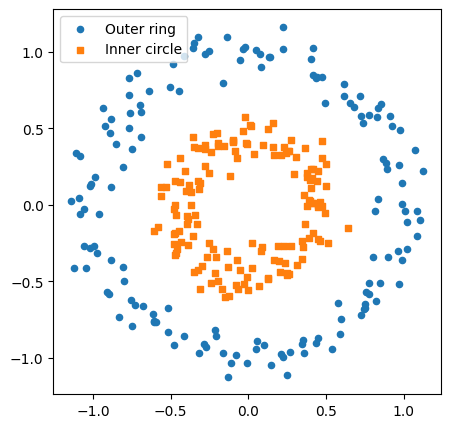

In [10]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X_c, y_c = make_circles(n_samples=300, noise=0.08, factor=0.45, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X_c, y_c, test_size=0.3, random_state=0, stratify=y_c)

plt.figure(figsize=(5, 5))
plt.scatter(X_c[y_c == 0, 0], X_c[y_c == 0, 1], color="tab:blue", s=20, label="Outer ring")
plt.scatter(X_c[y_c == 1, 0], X_c[y_c == 1, 1], color="tab:orange", marker="s", s=20, label="Inner circle")
plt.legend()
plt.show()

Let's try two SVMs:

- a **linear** kernel, which can only draw a straight line
- an **RBF** kernel, which can draw curves (this is the default in scikit-learn)

In [11]:
linear_model = SVC(kernel="linear").fit(X_train, y_train)
rbf_model = SVC(kernel="rbf").fit(X_train, y_train)

print("Linear kernel, test accuracy:", round(linear_model.score(X_test, y_test), 2))
print("RBF kernel, test accuracy:   ", round(rbf_model.score(X_test, y_test), 2))

Linear kernel, test accuracy: 0.51
RBF kernel, test accuracy:    1.0


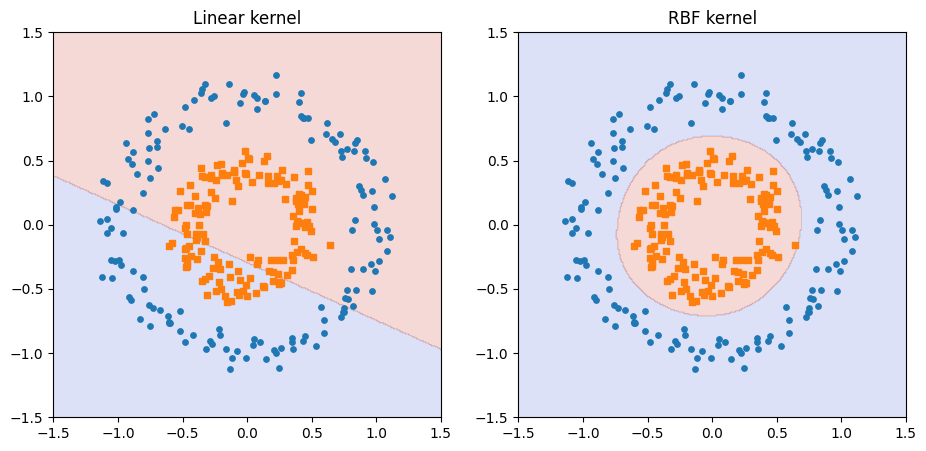

In [12]:
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, m, title in [(axes[0], linear_model, "Linear kernel"), (axes[1], rbf_model, "RBF kernel")]:
    regions = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, regions, alpha=0.2, cmap="coolwarm")
    ax.scatter(X_c[y_c == 0, 0], X_c[y_c == 0, 1], color="tab:blue", s=15)
    ax.scatter(X_c[y_c == 1, 0], X_c[y_c == 1, 1], color="tab:orange", marker="s", s=15)
    ax.set_title(title)

plt.show()

The straight line cuts right through both groups, so it does little better than guessing. The RBF kernel draws a circle around the inner group and gets almost everything right.

This is the **kernel trick**: it lets the SVM draw curved boundaries when a straight line is not enough.

## Summary

| Idea | What it means |
|---|---|
| Boundary | The SVM draws a line between the two groups |
| Margin | It picks the line with the widest gap on both sides |
| Support vectors | The few points on the edge of the gap. Only they decide where the line goes |
| Prediction | Work out a score. Negative means one group, positive means the other |
| Kernel | Linear for straight lines, RBF for curves |

## Things to try

1. In Step 6, make up your own new point. Work out its score by hand first, then check it with the model.
2. In Step 5, try deleting a **support vector** instead, such as `(2, 2)`. Does the line change this time?
3. In Step 3, change `C=1000` to `C=0.01`. Run Steps 3 to 5 again. What happens to the width of the margin and the number of support vectors?

In [13]:
# Your experiments here